In [1]:
import pandas as pd

df = pd.read_csv("/Users/abhinavpal/Downloads/DS projects/revenue project/data/OnlineRetail.csv", encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [3]:
df = df.dropna(subset=['CustomerID'])

In [4]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [5]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [6]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [7]:
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour

eda


<Axes: title={'center': 'Monthly Revenue'}, xlabel='Month'>

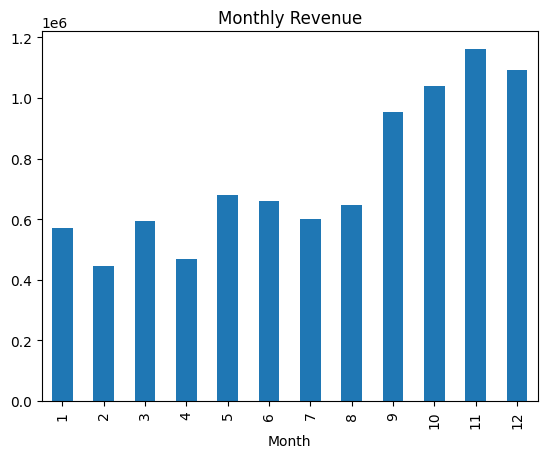

In [8]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()

monthly_revenue.plot(kind='bar', title='Monthly Revenue')

In [9]:
df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64

In [10]:
df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64

calculating customer value

In [11]:
customer_df = df.groupby('CustomerID').agg({
    'Revenue': 'sum',
    'InvoiceNo': 'count'
}).reset_index()

customer_df.columns = ['CustomerID', 'TotalRevenue', 'TotalTransactions']

In [12]:
customer_df['Segment'] = pd.qcut(customer_df['TotalRevenue'], 3, labels=['Low', 'Medium', 'High'])

product profitability

In [13]:
product_profit = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False)

In [14]:
forecast_df = df.groupby('InvoiceDate')['Revenue'].sum().reset_index()

In [15]:
forecast_df['Days'] = (forecast_df['InvoiceDate'] - forecast_df['InvoiceDate'].min()).dt.days

model training

In [16]:
from sklearn.linear_model import LinearRegression

X = forecast_df[['Days']]
y = forecast_df['Revenue']

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
future_days = pd.DataFrame({'Days': range(forecast_df['Days'].max(), forecast_df['Days'].max()+30)})
predictions = model.predict(future_days)

kpi metrics

In [18]:
total_revenue = df['Revenue'].sum()
total_customers = df['CustomerID'].nunique()
avg_order_value = df['Revenue'].mean()

In [19]:
df.to_csv('cleaned_revenue_data.csv', index=False)